In [52]:
import numpy as np
import pandas as pd

In [22]:
from typing import Optional, Tuple, Union

def load_and_clean_zip_csv(
    zip_path: str,
    file_name_a: str,
    file_name_b: Optional[str] = None
) -> Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]:
    """
    Load and clean CSV data from a zip archive with multi-row headers.

    Args:
        zip_path (str): Full path to the .zip file.
        file_name_a (str): Path to first CSV file inside the zip.
        file_name_b (Optional[str]): Path to optional second CSV inside the zip.

    Returns:
        Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]:
            Cleaned DataFrame from file A, and optional raw DataFrame from file B.
    """
    with zipfile.ZipFile(zip_path, 'r') as z:
        with z.open(file_name_a) as f1:
            df_A = pd.read_csv(f1)

        df_B = None
        if file_name_b:
            with z.open(file_name_b) as f2:
                df_B = pd.read_csv(f2)

    # Process headers from df_A
    headers = df_A.iloc[0:3].reset_index(drop=True)
    headers_T = headers.T

    clean_columns = []
    for _, row in headers_T.iterrows():
        if row[2] == "Date":
            clean_columns.append("Date")
        else:
            clean_columns.append(f"{row[0]}_{row[1]}_{row[2]}")

    df_cleaned = df_A.iloc[3:].reset_index(drop=True)
    df_cleaned.columns = clean_columns

    if df_B is not None:
        return df_cleaned, df_B
    return df_cleaned


In [ ]:
zip_path = "C:/Users/taiwoajayi/OneDrive - University of Arizona/GLOR/BUC-20250701T175818Z-1-001.zip"

df_NO = load_and_clean_zip_csv(zip_path, "BUC/BUC_NOdat_202506.CSV")
df_VOC = load_and_clean_zip_csv(zip_path, "BUC/BUC_VOCdat_202506.CSV")


In [24]:
df_NO

,Date,NO_T200U_PPB_Value,NO_T200U_PPB_Flags,NOY_PPB_Value,NOY_PPB_Flags,NOYDIF_PPB_Value,NOYDIF_PPB_Flags
0,01-Jun-2025 00:00,0.099,NaN,3.681,NaN,3.58,NaN
1,01-Jun-2025 01:00,0.219,NaN,3.593,NaN,3.37,NaN
2,01-Jun-2025 02:00,0.105,NaN,3.146,NaN,3.04,NaN
3,01-Jun-2025 03:00,-0.018,NaN,3.464,NaN,3.48,NaN
4,01-Jun-2025 04:00,0.033,NaN,2.956,NaN,2.92,NaN
...,...,...,...,...,...,...,...
715,30-Jun-2025 19:00,NaN,NaN,NaN,NaN,NaN,NaN
716,30-Jun-2025 20:00,NaN,NaN,NaN,NaN,NaN,NaN
717,30-Jun-2025 21:00,NaN,NaN,NaN,NaN,NaN,NaN
718,30-Jun-2025 22:00,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
print(df_NO['NOYDIF_PPB_Flags'].unique())

[nan '<' '>' 'P>' 'M<']


In [28]:
print(df_NO['NOY_PPB_Flags'].unique())

[nan '<' '>' 'P>' 'E' 'M<' 'M<H']


In [27]:
print(df_NO['NO_T200U_PPB_Flags'].unique())


[nan '<' '>' 'P>' 'M<']


In [60]:
unwanted_flags = ['>', 'P>', 'M<', 'B', 'C<', '>C', 'C<a', '<aC']
df_NO_filtered = df_NO[~df_NO['NO_T200U_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_NO_filtered


,Date,NO_T200U_PPB_Value,NO_T200U_PPB_Flags,NOY_PPB_Value,NOY_PPB_Flags,NOYDIF_PPB_Value,NOYDIF_PPB_Flags
0,01-Jun-2025 00:00,0.099,NaN,3.681,NaN,3.58,NaN
1,01-Jun-2025 01:00,0.219,NaN,3.593,NaN,3.37,NaN
2,01-Jun-2025 02:00,0.105,NaN,3.146,NaN,3.04,NaN
3,01-Jun-2025 03:00,-0.018,NaN,3.464,NaN,3.48,NaN
4,01-Jun-2025 04:00,0.033,NaN,2.956,NaN,2.92,NaN
...,...,...,...,...,...,...,...
705,30-Jun-2025 19:00,NaN,NaN,NaN,NaN,NaN,NaN
706,30-Jun-2025 20:00,NaN,NaN,NaN,NaN,NaN,NaN
707,30-Jun-2025 21:00,NaN,NaN,NaN,NaN,NaN,NaN
708,30-Jun-2025 22:00,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df_VOC

,Date,"1,2,3-Trimethylbenzene_HR_PPB_Value","1,2,3-Trimethylbenzene_HR_PPB_Flags","1,2,4-Trimethylbenzene_HR_PPB_Value","1,2,4-Trimethylbenzene_HR_PPB_Flags","1,3,5-Trimethylbenzene_HR_PPB_Value","1,3,5-Trimethylbenzene_HR_PPB_Flags","1,3-Butadiene_HR_PPB_Value","1,3-Butadiene_HR_PPB_Flags",1-Butene_HR_PPB_Value,...,TNMOC_BP_PPB_Value,TNMOC_BP_PPB_Flags,TNMOC_PLOT_PPB_Value,TNMOC_PLOT_PPB_Flags,Toluene_HR_PPB_Value,Toluene_HR_PPB_Flags,trans-2-Butene_HR_PPB_Value,trans-2-Butene_HR_PPB_Flags,trans-2-Pentene_HR_PPB_Value,trans-2-Pentene_HR_PPB_Flags
0,01-Jun-2025 00:00,0.01,B,0.02,B,0.01,B,0,B,0,...,2.85,B,4.48,B,0.3,B,0.17,B,0,B
1,01-Jun-2025 01:00,2.81,C<,3.95,C<,2.67,C<,4.79,C<,0,...,NaN,NaN,NaN,NaN,6.34,C<,6.11,C<,4.91,C<
2,01-Jun-2025 02:00,0.07,NaN,0.14,NaN,0.05,NaN,0.05,NaN,0.04,...,8.39,NaN,6.68,NaN,0.63,NaN,0.2,NaN,0,NaN
3,01-Jun-2025 03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01-Jun-2025 04:00,0.02,NaN,0.04,NaN,0.08,NaN,0.09,NaN,0,...,6.99,NaN,6.19,NaN,0.65,NaN,0.1,NaN,0.02,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,30-Jun-2025 19:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
716,30-Jun-2025 20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
717,30-Jun-2025 21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
718,30-Jun-2025 22:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
list(df_VOC.columns)

['Date',
 '1,2,3-Trimethylbenzene_HR_PPB_Value',
 '1,2,3-Trimethylbenzene_HR_PPB_Flags',
 '1,2,4-Trimethylbenzene_HR_PPB_Value',
 '1,2,4-Trimethylbenzene_HR_PPB_Flags',
 '1,3,5-Trimethylbenzene_HR_PPB_Value',
 '1,3,5-Trimethylbenzene_HR_PPB_Flags',
 '1,3-Butadiene_HR_PPB_Value',
 '1,3-Butadiene_HR_PPB_Flags',
 '1-Butene_HR_PPB_Value',
 '1-Butene_HR_PPB_Flags',
 '1-Hexene_HR_PPB_Value',
 '1-Hexene_HR_PPB_Flags',
 '1-Pentene_HR_PPB_Value',
 '1-Pentene_HR_PPB_Flags',
 '2,2,4-Trimethylpentane_HR_PPB_Value',
 '2,2,4-Trimethylpentane_HR_PPB_Flags',
 '2,2-Dimethylbutane_HR_PPB_Value',
 '2,2-Dimethylbutane_HR_PPB_Flags',
 '2,3,4-Trimethylpentane_HR_PPB_Value',
 '2,3,4-Trimethylpentane_HR_PPB_Flags',
 '2,3-Dimethylbutane_HR_PPB_Value',
 '2,3-Dimethylbutane_HR_PPB_Flags',
 '2,3-Dimethylpentane_HR_PPB_Value',
 '2,3-Dimethylpentane_HR_PPB_Flags',
 '2,4-Dimethylpentane_HR_PPB_Value',
 '2,4-Dimethylpentane_HR_PPB_Flags',
 '2-Methylheptane_HR_PPB_Value',
 '2-Methylheptane_HR_PPB_Flags',
 '2-Methylhex

In [43]:
unwanted_flags = ['>', 'P>', 'M<', 'B', 'C<', '>C', 'C<a', '<aC']
df_VOC_filtered = df_VOC[~df_VOC['1,2,4-Trimethylbenzene_HR_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_VOC_filtered

,Date,"1,2,3-Trimethylbenzene_HR_PPB_Value","1,2,3-Trimethylbenzene_HR_PPB_Flags","1,2,4-Trimethylbenzene_HR_PPB_Value","1,2,4-Trimethylbenzene_HR_PPB_Flags","1,3,5-Trimethylbenzene_HR_PPB_Value","1,3,5-Trimethylbenzene_HR_PPB_Flags","1,3-Butadiene_HR_PPB_Value","1,3-Butadiene_HR_PPB_Flags",1-Butene_HR_PPB_Value,...,TNMOC_BP_PPB_Value,TNMOC_BP_PPB_Flags,TNMOC_PLOT_PPB_Value,TNMOC_PLOT_PPB_Flags,Toluene_HR_PPB_Value,Toluene_HR_PPB_Flags,trans-2-Butene_HR_PPB_Value,trans-2-Butene_HR_PPB_Flags,trans-2-Pentene_HR_PPB_Value,trans-2-Pentene_HR_PPB_Flags
0,01-Jun-2025 02:00,0.07,NaN,0.14,NaN,0.05,NaN,0.05,NaN,0.04,...,8.39,NaN,6.68,NaN,0.63,NaN,0.2,NaN,0,NaN
1,01-Jun-2025 03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01-Jun-2025 04:00,0.02,NaN,0.04,NaN,0.08,NaN,0.09,NaN,0,...,6.99,NaN,6.19,NaN,0.65,NaN,0.1,NaN,0.02,NaN
3,01-Jun-2025 05:00,0.02,NaN,0.06,NaN,0.04,NaN,0.02,NaN,0,...,6.97,NaN,6.03,NaN,0.67,NaN,0.19,NaN,0,NaN
4,01-Jun-2025 06:00,0.01,NaN,0.04,NaN,0,NaN,0.03,NaN,0.21,...,6.24,NaN,6.33,NaN,0.64,NaN,0.16,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642,30-Jun-2025 19:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
643,30-Jun-2025 20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
644,30-Jun-2025 21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
645,30-Jun-2025 22:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
zip_path = "C:/Users/taiwoajayi/OneDrive - University of Arizona/GLOR/QUV-20250701T175834Z-1-001.zip"

QUV_NO = load_and_clean_zip_csv(zip_path, "QUV/QUV_NOdat_202506.CSV")
QUV_VOC = load_and_clean_zip_csv(zip_path, "QUV/QUV_VOCdat_202506.CSV")

In [56]:
df_VOC_QUV = QUV_VOC[~QUV_VOC['1,2,4-Trimethylbenzene_HR_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_VOC_QUV
df_NO_QUV = QUV_NO[~QUV_NO['NO_T200U_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_NO_QUV
date_cols = ['Date']
# Convert all other columns to numeric
df_NO_QUV[df_NO_QUV.columns.difference(date_cols)] = df_NO_QUV[df_NO_QUV.columns.difference(date_cols)].apply(
    pd.to_numeric, errors='coerce'
)

# NO2 / NO (only where both exist and NO ≠ 0)
df_NO_QUV['NO2_to_NO_ratio'] = np.where(
    df_NO_QUV['NO_N500_PPB_Value'].notna() &
    df_NO_QUV['NO2_PPB_Value'].notna() &
    (df_NO_QUV['NO_N500_PPB_Value'] != 0),
    df_NO_QUV['NO2_PPB_Value'] / df_NO_QUV['NO_N500_PPB_Value'],
    np.nan
)

df_NO_QUV['NOx_to_NOy_ratio'] = np.where(
    df_NO_QUV['NOX_PPB_Value'].notna() &
    df_NO_QUV['NOY_PPB_Value'].notna() &
    (df_NO_QUV['NOY_PPB_Value'] != 0),
    df_NO_QUV['NOX_PPB_Value'] / df_NO_QUV['NOY_PPB_Value'],
    np.nan
)

In [36]:
zip_path = "C:/Users/taiwoajayi/OneDrive - University of Arizona/GLOR/JLG-20250701T175823Z-1-001.zip"

#JLG_NO = load_and_clean_zip_csv(zip_path, "JLG/JLG_NOdat_202506.CSV")
JLG_VOC = load_and_clean_zip_csv(zip_path, "JLG/JLG_VOCdat_202506.CSV")

In [48]:
df_VOC_JLG = JLG_VOC[~JLG_VOC['1,2,4-Trimethylbenzene_HR_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_VOC_JLG
#df_NO_JLG = JLG_NO[~JLG_NO['NO_T200U_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
#df_NO_JLG

,Date,"1,2,3-Trimethylbenzene_HR_PPB_Value","1,2,3-Trimethylbenzene_HR_PPB_Flags","1,2,4-Trimethylbenzene_HR_PPB_Value","1,2,4-Trimethylbenzene_HR_PPB_Flags","1,3,5-Trimethylbenzene_HR_PPB_Value","1,3,5-Trimethylbenzene_HR_PPB_Flags","1,3-Butadiene_HR_PPB_Value","1,3-Butadiene_HR_PPB_Flags",1-Butene_HR_PPB_Value,...,TNMOC_BP_PPB_Value,TNMOC_BP_PPB_Flags,TNMOC_PLOT_PPB_Value,TNMOC_PLOT_PPB_Flags,Toluene_HR_PPB_Value,Toluene_HR_PPB_Flags,trans-2-Butene_HR_PPB_Value,trans-2-Butene_HR_PPB_Flags,trans-2-Pentene_HR_PPB_Value,trans-2-Pentene_HR_PPB_Flags
0,01-Jun-2025 00:00,0.02,NaN,0.05,NaN,0.02,NaN,0.03,NaN,0,...,1.55,NaN,3.42,NaN,0.19,NaN,0.03,NaN,0,NaN
1,01-Jun-2025 01:00,0.02,NaN,0.05,NaN,0.01,NaN,0.04,NaN,0,...,1.69,NaN,3.74,NaN,0.21,NaN,0.02,NaN,0,NaN
2,01-Jun-2025 02:00,0.01,NaN,0.04,NaN,0.01,NaN,0.02,NaN,0,...,1.02,NaN,2.01,NaN,0.13,NaN,0.02,NaN,0,NaN
3,01-Jun-2025 03:00,0.01,NaN,0.04,NaN,0.01,NaN,0,NaN,0,...,0.99,NaN,3.91,NaN,0.14,NaN,0.02,NaN,0,NaN
4,01-Jun-2025 04:00,0.02,NaN,0.04,NaN,0.01,NaN,0,NaN,0,...,2.14,NaN,3.52,NaN,0.34,NaN,0.02,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,30-Jun-2025 19:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
620,30-Jun-2025 20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
621,30-Jun-2025 21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
622,30-Jun-2025 22:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
zip_path = "C:/Users/taiwoajayi/OneDrive - University of Arizona/GLOR/HIG-20250701T175831Z-1-001.zip"

HIG_NO = load_and_clean_zip_csv(zip_path, "HIG/HIG_NOdat_202506.CSV")
HIG_VOC = load_and_clean_zip_csv(zip_path, "HIG/HIG_VOCdat_202506.CSV")

In [55]:
df_VOC_HIG = HIG_VOC[~HIG_VOC['1,2,4-Trimethylbenzene_HR_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_VOC_HIG
df_NO_HIG = HIG_NO[~HIG_NO['NO_T200U_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_NO_HIG
date_cols = ['Date']
# Convert all other columns to numeric
df_NO_HIG[df_NO_HIG.columns.difference(date_cols)] = df_NO_HIG[df_NO_HIG.columns.difference(date_cols)].apply(
    pd.to_numeric, errors='coerce'
)

# NO2 / NO (only where both exist and NO ≠ 0)
df_NO_HIG['NO2_to_NO_ratio'] = np.where(
    df_NO_HIG['NO_N500_PPB_Value'].notna() &
    df_NO_HIG['NO2_PPB_Value'].notna() &
    (df_NO_HIG['NO_N500_PPB_Value'] != 0),
    df_NO_HIG['NO2_PPB_Value'] / df_NO_HIG['NO_N500_PPB_Value'],
    np.nan
)

df_NO_HIG['NOx_to_NOy_ratio'] = np.where(
    df_NO_HIG['NOX_PPB_Value'].notna() &
    df_NO_HIG['NOY_PPB_Value'].notna() &
    (df_NO_HIG['NOY_PPB_Value'] != 0),
    df_NO_HIG['NOX_PPB_Value'] / df_NO_HIG['NOY_PPB_Value'],
    np.nan
)

In [32]:
zip_path = "C:/Users/taiwoajayi/OneDrive - University of Arizona/GLOR/FOH-20250701T175820Z-1-001.zip"

FOH_NO = load_and_clean_zip_csv(zip_path, "FOH/FOH_NOdat_202506.CSV")
FOH_VOC = load_and_clean_zip_csv(zip_path, "FOH/FOH_VOCdat_202506.CSV")

In [54]:
df_VOC_FOH = FOH_VOC[~FOH_VOC['1,2,4-Trimethylbenzene_HR_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_VOC_FOH
df_NO_FOH = FOH_NO[~FOH_NO['NO_T200U_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_NO_FOH
# Convert all other columns to numeric
df_NO_FOH[df_NO_FOH.columns.difference(date_cols)] = df_NO_FOH[df_NO_FOH.columns.difference(date_cols)].apply(
    pd.to_numeric, errors='coerce'
)
date_cols = ['Date']
# NO2 / NO (only where both exist and NO ≠ 0)
df_NO_FOH['NO2_to_NO_ratio'] = np.where(
    df_NO_FOH['NO_N500_PPB_Value'].notna() &
    df_NO_FOH['NO2_PPB_Value'].notna() &
    (df_NO_FOH['NO_N500_PPB_Value'] != 0),
    df_NO_FOH['NO2_PPB_Value'] / df_NO_FOH['NO_N500_PPB_Value'],
    np.nan
)

df_NO_FOH['NOx_to_NOy_ratio'] = np.where(
    df_NO_FOH['NOX_PPB_Value'].notna() &
    df_NO_FOH['NOY_PPB_Value'].notna() &
    (df_NO_FOH['NOY_PPB_Value'] != 0),
    df_NO_FOH['NOX_PPB_Value'] / df_NO_FOH['NOY_PPB_Value'],
    np.nan
)

In [31]:
zip_path = "C:/Users/taiwoajayi/OneDrive - University of Arizona/GLOR/DUC-20250701T175827Z-1-001.zip"

DUC_NO = load_and_clean_zip_csv(zip_path, "DUC/DUC_NOdat_202506.CSV")
DUC_VOC = load_and_clean_zip_csv(zip_path, "DUC/DUC_VOCdat_202506.CSV")

In [92]:
df_VOC_DUC = DUC_VOC[~DUC_VOC['1,2,4-Trimethylbenzene_HR_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_VOC_DUC
df_NO_DUC = DUC_NO[~DUC_NO['NO_T200U_PPB_Flags'].isin(unwanted_flags)].reset_index(drop=True)
df_NO_DUC

# Specify the date column(s) to exclude
date_cols = ['Date']

# Convert all other columns to numeric
df_NO_DUC[df_NO_DUC.columns.difference(date_cols)] = df_NO_DUC[df_NO_DUC.columns.difference(date_cols)].apply(
    pd.to_numeric, errors='coerce'
)

# NO2 / NO (only where both exist and NO ≠ 0)
df_NO_DUC['NO2_to_NO_ratio'] = np.where(
    df_NO_DUC['NO_N500_PPB_Value'].notna() &
    df_NO_DUC['NO2_PPB_Value'].notna() &
    (df_NO_DUC['NO_N500_PPB_Value'] != 0),
    df_NO_DUC['NO2_PPB_Value'] / df_NO_DUC['NO_N500_PPB_Value'],
    np.nan
)

df_NO_DUC['NOx_to_NOy_ratio'] = np.where(
    df_NO_DUC['NOX_PPB_Value'].notna() &
    df_NO_DUC['NOY_PPB_Value'].notna() &
    (df_NO_DUC['NOY_PPB_Value'] != 0),
    df_NO_DUC['NOX_PPB_Value'] / df_NO_DUC['NOY_PPB_Value'],
    np.nan
)


In [64]:
list(df_NO_DUC.columns)

['Date',
 'NO_N500_PPB_Value',
 'NO_N500_PPB_Flags',
 'NO_T200U_PPB_Value',
 'NO_T200U_PPB_Flags',
 'NO2_PPB_Value',
 'NO2_PPB_Flags',
 'NOX_PPB_Value',
 'NOX_PPB_Flags',
 'NOY_PPB_Value',
 'NOY_PPB_Flags',
 'NOYDIF_PPB_Value',
 'NOYDIF_PPB_Flags',
 'NO2_to_NO_ratio',
 'NOx_to_NOy_ratio']

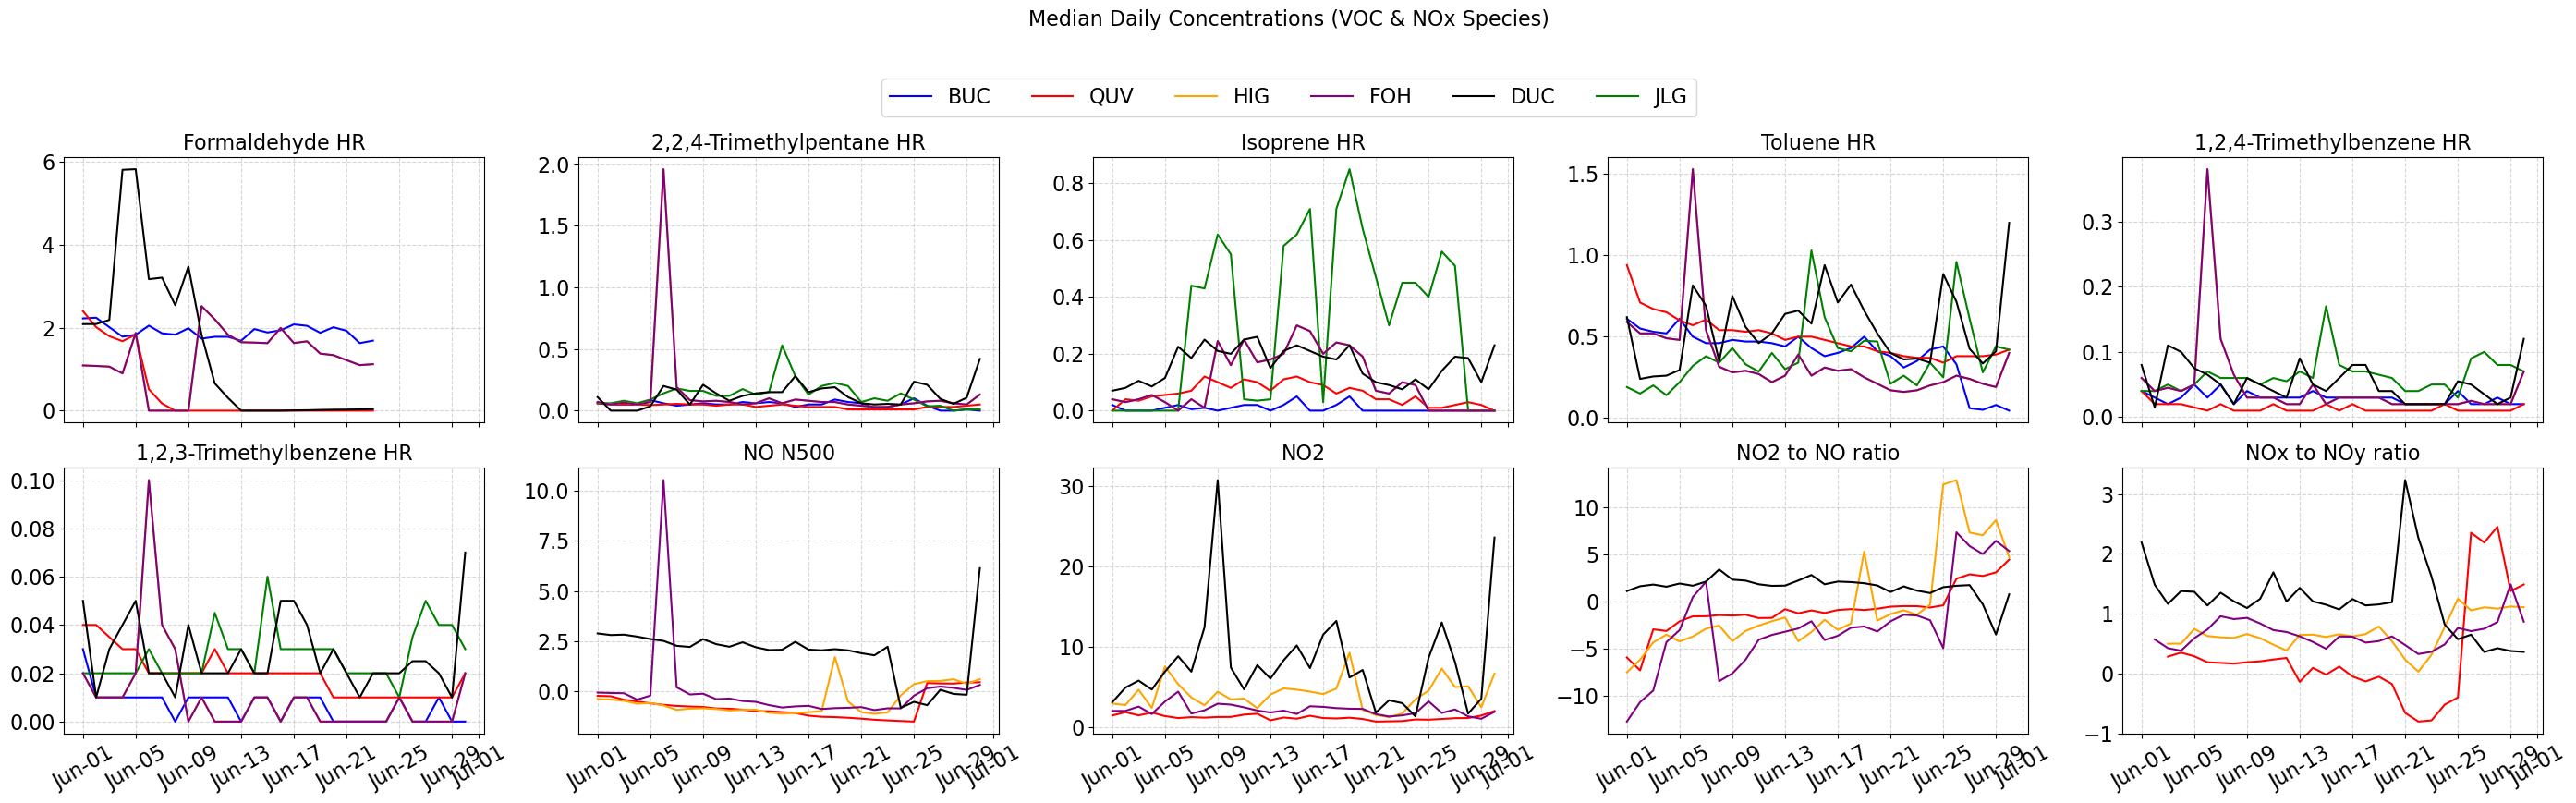

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Species to plot ---
species_list = [
    'Formaldehyde_HR_PPB_Value',
    '2,2,4-Trimethylpentane_HR_PPB_Value',
    'Isoprene_HR_PPB_Value',
    'Toluene_HR_PPB_Value',
    '1,2,4-Trimethylbenzene_HR_PPB_Value',
    '1,2,3-Trimethylbenzene_HR_PPB_Value',
    'NO_N500_PPB_Value',
    'NO2_PPB_Value',
    'NO2_to_NO_ratio',
    'NOx_to_NOy_ratio'
]

# --- VOC datasets ---
voc_datasets = {
    'BUC': df_VOC_filtered,
    'QUV': df_VOC_QUV,
    'JLG': df_VOC_JLG,
    'HIG': df_VOC_HIG,
    'FOH': df_VOC_FOH,
    'DUC': df_VOC_DUC
}

# --- NO datasets (BUC & JLG excluded) ---
no_datasets = {
    'QUV': df_NO_QUV,
    'HIG': df_NO_HIG,
    'FOH': df_NO_FOH,
    'DUC': df_NO_DUC,
}

# --- Consistent site color map ---
color_map = {
    'BUC': 'blue',
    'QUV': 'red',
    'JLG': 'green',
    'HIG': 'orange',
    'FOH': 'purple',
    'DUC': 'black'
}

# --- Plot Setup ---
fig, axes = plt.subplots(2, 5, figsize=(28, 8), sharex=True)
axes = axes.flatten()

for i, species in enumerate(species_list):
    ax = axes[i]

    # Select dataset group
    if any(species in df.columns for df in voc_datasets.values()):
        dataset_group = voc_datasets
    elif any(species in df.columns for df in no_datasets.values()):
        dataset_group = no_datasets
    else:
        ax.set_title(f"{species} (Not Found)", fontsize=11)
        continue

    # Plot species for each site
    for label, df in dataset_group.items():
        if species in df.columns:
            try:
                df_daily = df.dropna(subset=[species]).copy()
                df_daily[species] = pd.to_numeric(df_daily[species], errors='coerce')
                df_daily['Date'] = pd.to_datetime(df_daily['Date'])
                median_series = df_daily.groupby(df_daily['Date'].dt.date)[species].median()
                ax.plot(median_series.index, median_series.values, label=label, color=color_map.get(label, 'gray'))
            except Exception as e:
                print(f"⚠️ Error plotting {label} for {species}: {e}")

    # Formatting
    ax.set_title(species.replace('_PPB_Value', '').replace('_', ' '), fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='y', labelsize=16)

    if i < 5:
        ax.set_xticklabels([])
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
        ax.tick_params(axis='x', rotation=30, labelsize=16)

# --- Shared Legend (only real plotted labels) ---
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.), ncol=6, fontsize=16)

fig.suptitle("Median Daily Concentrations (VOC & NOx Species)", fontsize=16, y=1.08)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()
